In [16]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')


True

In [17]:
model = ChatOpenAI(model_name='gpt-4', temperature=0)


In [18]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis:dict
    response:str


In [20]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative']=Field(description="The sentiment of the review, either 'positive' or 'negative'")

In [21]:
structured_model = model.with_structured_output(SentimentSchema)

f:\agentic_ai\AgenticAIWorkspace\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1949: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [22]:
prompt = f"""The software is too bad"""
structured_model.invoke(prompt)

SentimentSchema(sentiment='negative')

In [29]:
def find_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"""For the following review, find the sentiment (either 'positive' or 'negative').
    \n Review: {state['review']}"""
    review = state['review']
    sentiment= structured_model.invoke(review).sentiment
    state['sentiment'] = sentiment
    return {'sentiment':sentiment}

In [82]:
class DiagnosisSchema(BaseModel):
    issue_type:  Literal['bug','feature_request','performance','usability']=Field(description="The type of issue reported in the review")
    tone: Literal['apologetic','neutral','enthusiastic']=Field(description="The tone to be used in the response")
    urgency: Literal['low','medium','high']=Field(description="The urgency level of the response")
    

diagnosis_model = model.with_structured_output(DiagnosisSchema)

f:\agentic_ai\AgenticAIWorkspace\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1949: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [86]:
def check_sentiment(state:ReviewState) ->Literal['positive_respone','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_respone'
    else:
        return 'run_diagnosis'

def positive_response(state:ReviewState) -> ReviewState:
    prompt = f"""
    Write a warm thank you message in response to the following positive review.
    \n Review: {state['review']}. 
    Also kindly ask the user to leave feedback on our website"""
    response = model.invoke(prompt).content
    
    state['response'] = response
    return {'response':response}

def run_diagnosis(state:ReviewState) -> ReviewState:
    prompt = f"""
    Diagnose the issue in the following negative review and suggest improvements.
    \n Review: {state['review']}
    Return issue type,tone and urgency
    """
    response = diagnosis_model.invoke(prompt)
    # print(diagnosis)
    # state['diagnosis'] = diagnosis
    return {'diagnosis':response.model_dump()}






def negative_response(state:ReviewState) -> ReviewState:
    diagnosis = state['diagnosis']
    prompt = f"""
    The user had a {state['diagnosis']['issue_type']} issue     
    and the review tone is {state['diagnosis']['tone']} with an urgency level of {state['diagnosis']['urgency']}.
    Write a response to the following negative review based on the diagnosis provided.
    \n Review: {state['review']}
    \n Diagnosis: Issue Type - {state['diagnosis']['issue_type']}, Tone - {state['diagnosis']['tone']}, Urgency - {state['diagnosis']['urgency']}
    Write a empathetic and solution-focused response addressing the user's concerns.
    """
    response = model.invoke(prompt).content
    state['response'] = response
    return {'response':response}    

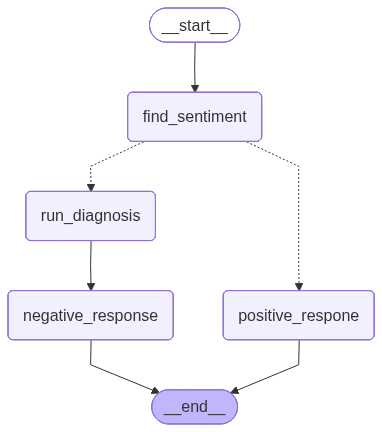

In [87]:
graph = StateGraph(ReviewState)

#add nodes
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_respone',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


#add edge
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_respone',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)



workflow = graph.compile()
workflow 

In [88]:
initial_state = {'review': "The software is too bad"}
result = workflow.invoke(initial_state)
result

{'review': 'The software is too bad',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'usability',
  'tone': 'apologetic',
  'urgency': 'high'},
 'response': "Dear User,\n\nI'm truly sorry to hear about the difficulties you've been experiencing with our software. We understand how frustrating it can be when things don't work as expected, and we sincerely apologize for any inconvenience this may have caused you.\n\nWe take your feedback very seriously and we're committed to providing the best possible user experience. We would appreciate it if you could provide us with more specific details about the issues you're facing. This will help us to identify the problem and work on a solution as quickly as possible.\n\nPlease feel free to reach out to our support team at your earliest convenience. We're here to help and we're eager to resolve this issue for you as soon as possible. \n\nThank you for your patience and understanding.\n\nBest Regards,\n[Your Name]"}